In [1]:
import os
import time
import calendar

import numpy as np
import pandas as pd
import requests
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

np.random.seed(42)
print('All imports successful.')

All imports successful.


## Constants

In [2]:
COLOMBO_AREA_COORDS = {
    'MORATUWA NORTH': {'lat': 6.7800, 'lon': 79.8833},
    'MORATUWA SOUTH': {'lat': 6.7688, 'lon': 79.8800},
    'MAHARAGAMA':     {'lat': 6.8400, 'lon': 79.9280},
    'BORALASGAMUWA':  {'lat': 6.8600, 'lon': 79.9170},
    'PITA-KOTTE':     {'lat': 6.9000, 'lon': 79.9200},
    'KOLONNAWA':      {'lat': 6.9489, 'lon': 79.9004},
    'KOTIKAWATTA':    {'lat': 6.9460, 'lon': 79.8860},
    'NUGEGODA':       {'lat': 6.8410, 'lon': 79.9189},
}

FEATURE_COLS = [
    'members', 'avg_prev_bill', 'prev_month_consumption',
    'std_prev_3months', 'consumption_trend',
    'fan_count', 'fan_hours_per_month',
    'ac_count', 'ac_hours_per_month', 'ac_tons', 'fridge_count',
    'washer_hours_per_month', 'heater_hours_per_month',
    'other_hours_per_month', 'avg_temp', 'avg_humidity',
    'total_precip', 'avg_wind', 'month',
    'ac_kwh_est', 'total_load_est',
]

MODEL_SAVE_PATH    = 'backend/ml/model.pkl'
TRAINING_DATA_PATH = 'data/processed/training_dataset.csv'

print('Constants ready.')
print(f'Total features: {len(FEATURE_COLS)}')

Constants ready.
Total features: 21


## Step 1 — Load Raw Data

In [3]:
consumption = pd.read_csv(
    'data/raw/consumption_data/non_smart_meter/monthly_consumption.csv',
    thousands=','
)
ac         = pd.read_csv('data/raw/survey_data/wave_1/w1_ac_roster.csv')
fan        = pd.read_csv('data/raw/survey_data/wave_1/w1_fan_roster.csv')
appliances = pd.read_csv('data/raw/survey_data/wave_1/w1_appliances.csv')
household  = pd.read_csv('data/raw/survey_data/wave_1/w1_household_information_and_history.csv')

n_hh     = consumption['household_ID'].nunique()
n_months = consumption['month'].nunique()
print(f'Consumption : {len(consumption):,} rows | {n_hh:,} households | {n_months} months')
print(f'AC roster   : {len(ac):,} rows')
print(f'Fan roster  : {len(fan):,} rows')
print(f'Appliances  : {len(appliances):,} rows')
print(f'Household   : {len(household):,} rows')
consumption.head(3)

Consumption : 101,575 rows | 4,063 households | 25 months
AC roster   : 1,171 rows
Fan roster  : 13,525 rows
Appliances  : 53,599 rows
Household   : 4,063 rows


,household_ID,month,consumption
0,ID0001,2022-10-31,116.0
1,ID0001,2022-11-30,120.0
2,ID0001,2022-12-31,129.0


In [4]:
consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 101575 entries, 0 to 101574
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   household_ID  101575 non-null  str    
 1   month         101575 non-null  str    
 2   consumption   100985 non-null  float64
dtypes: float64(1), str(2)
memory usage: 2.3 MB


In [5]:
missing_before = consumption['consumption'].isna().sum()

consumption['consumption'] = consumption.groupby('household_ID')['consumption'] \
    .transform(lambda x: x.fillna(x.mean()))

consumption['consumption'] = consumption['consumption']

missing_after = consumption['consumption'].isna().sum()
print(f'Filled missing consumption values per household. Nulls before: {missing_before}, after: {missing_after}')

Filled missing consumption values per household. Nulls before: 590, after: 0


In [6]:
consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 101575 entries, 0 to 101574
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   household_ID  101575 non-null  str    
 1   month         101575 non-null  str    
 2   consumption   101575 non-null  float64
dtypes: float64(1), str(2)
memory usage: 2.3 MB


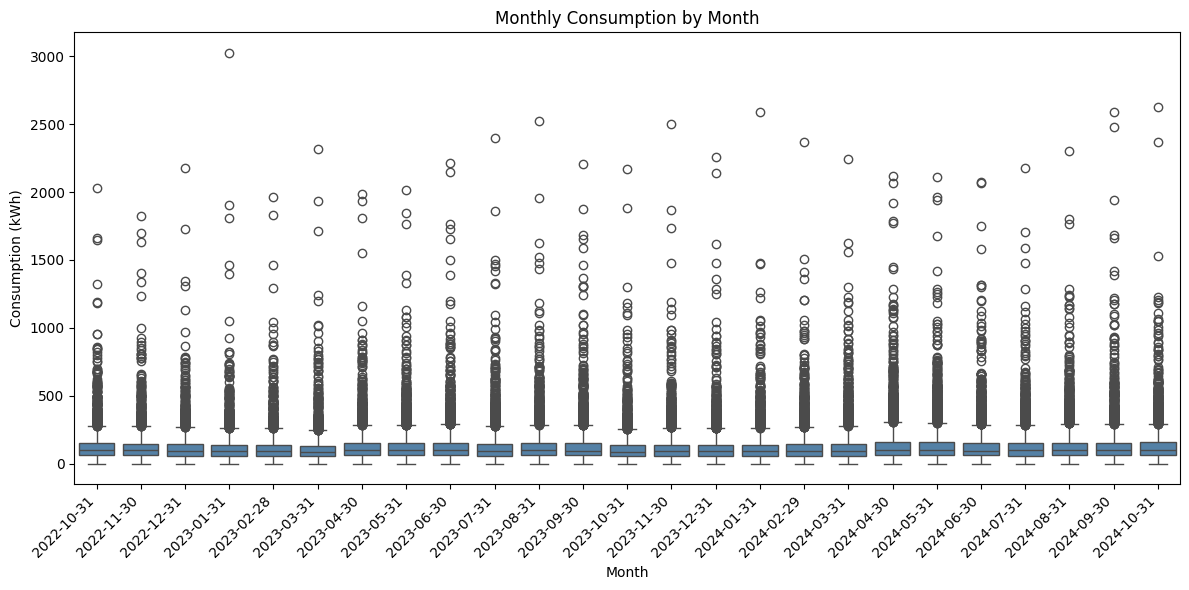

In [7]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='consumption', data=consumption, color='steelblue')
plt.title('Monthly Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Consumption (kWh)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [8]:
before_outlier = len(consumption)
consumption = consumption[consumption['consumption'] <= 1000]
after_outlier = len(consumption)
print(f'Removed {before_outlier - after_outlier} consumption outliers (>1000 kWh)')
print(f'Dataset shape after outlier removal: {consumption.shape}')

Removed 245 consumption outliers (>1000 kWh)
Dataset shape after outlier removal: (101330, 3)


## Step 2 — Process AC Data

Convert BTU to tons of refrigeration (1 ton = 12,000 BTU/hr).  
Missing BTU is filled with 18,000 (1.5 ton — most common size in Sri Lanka).  
Households with zero AC hours have no AC — their contribution to consumption is 0.

In [9]:
# Keep only the first "Central" AC row per household (drop other room-level duplicates)
central_mask = ac['type_of_the_ac'].str.contains('Central', na=False)

dup_idx = []
for hid, grp in ac[central_mask].groupby('household_ID'):
    if len(grp) > 1:
        dup_idx.extend(grp.index.tolist()[1:])

print(f'Dropping {len(dup_idx)} duplicate central-AC rows for {len(set(ac.loc[dup_idx, "household_ID"]))} households')
if dup_idx:
    ac.drop(index=dup_idx, inplace=True)
    ac.reset_index(drop=True, inplace=True)

print('ac shape after deduplication:', ac.shape)
ac.head(20)


Dropping 231 duplicate central-AC rows for 52 households
ac shape after deduplication: (940, 10)


,household_ID,room_ID,ac_ID,type_of_the_ac,is_the_ac_inverter_or_not,is_room_fully_sealed,wattage_of_the_ac,btu_of_the_ac,no_of_hours_ac_was_on_during_daytime_last_week,no_of_hours_ac_was_on_during_night_last_week
0,ID0012,I3,I3_AC1,Individual AC with one component,Yes,The room can be fully closed and sealed and th...,1500.0,NaN,0.0,45.00
1,ID0014,I3,I3_AC1,Other,No,The room can be fully closed and sealed and th...,0.0,NaN,0.0,0.00
2,ID0018,I5,I5_AC1,Individual AC with two components,Yes,The room can be fully closed and sealed and th...,2000.0,NaN,0.0,56.00
3,ID0025,I2,I2_AC1,Central AC (Only to your Household),Yes,The room can be fully closed and sealed and th...,0.0,NaN,0.0,0.00
4,ID0039,I8,I8_AC1,Individual AC with two components,Yes,The room can be fully closed and sealed and th...,0.0,NaN,12.0,12.00
5,ID0039,I9,I9_AC1,Individual AC with two components,Yes,The room can be fully closed and sealed and th...,0.0,9000.0,12.0,12.00
6,ID0041,I8,I8_AC1,Air Cooler,Yes,The room can be fully closed and sealed and th...,0.0,NaN,0.0,21.00
7,ID0043,I3,I3_AC1,Individual AC with two components,No,The room can be fully closed and sealed and th...,0.0,NaN,0.0,0.00
8,ID0043,I18,I18_AC1,Individual AC with two components,No,The room can be fully closed and sealed and th...,0.0,NaN,42.0,21.00
9,ID0043,I19,I19_AC1,Individual AC with two components,No,The room can be fully closed and sealed and th...,0.0,NaN,42.0,42.00


In [10]:
'''ac['total_ac_hours_last_week'] = (
    ac['no_of_hours_ac_was_on_during_daytime_last_week'].fillna(0) +
    ac['no_of_hours_ac_was_on_during_night_last_week'].fillna(0)
)
ac['ac_hours_per_month'] = ac['total_ac_hours_last_week'] * 4.33
ac['ac_tons'] = ac['btu_of_the_ac'].fillna(18000) / 12000

ac_agg = ac.groupby('household_ID').agg(
    ac_count=('ac_ID', 'count'),
    ac_hours_per_month=('ac_hours_per_month', 'sum'),
    ac_tons=('ac_tons', 'mean')
).reset_index()

print('AC aggregated:', ac_agg.shape)
ac_agg.head(3)'''

"ac['total_ac_hours_last_week'] = (\n    ac['no_of_hours_ac_was_on_during_daytime_last_week'].fillna(0) +\n    ac['no_of_hours_ac_was_on_during_night_last_week'].fillna(0)\n)\nac['ac_hours_per_month'] = ac['total_ac_hours_last_week'] * 4.33\nac['ac_tons'] = ac['btu_of_the_ac'].fillna(18000) / 12000\n\nac_agg = ac.groupby('household_ID').agg(\n    ac_count=('ac_ID', 'count'),\n    ac_hours_per_month=('ac_hours_per_month', 'sum'),\n    ac_tons=('ac_tons', 'mean')\n).reset_index()\n\nprint('AC aggregated:', ac_agg.shape)\nac_agg.head(3)"

## Step 3 — Process Fan Data

Zero fan hours = no fans at that household.

In [11]:
fan['total_fan_hours_last_week'] = (
    fan['no_of_hours_fan_was_on_during_daytime_last_week'].fillna(0) +
    fan['no_of_hours_fan_was_on_during_night_last_week'].fillna(0)
)
fan['fan_hours_per_month'] = fan['total_fan_hours_last_week'] * 4.33

fan_agg = fan.groupby('household_ID').agg(
    fan_count=('fan_ID', 'count'),
    fan_hours_per_month=('fan_hours_per_month', 'sum')
).reset_index()

print('Fan aggregated:', fan_agg.shape)
fan_agg.head(3)

Fan aggregated: (3817, 3)


,household_ID,fan_count,fan_hours_per_month
0,ID0001,5,0.00
1,ID0002,14,935.28
2,ID0003,2,294.44


## Step 4 — Process Other Appliances

Zero hours = appliance not used (treated as not present). No kWh is estimated or assumed.

In [12]:
appliances['no_of_hours_used_during_last_week'] = pd.to_numeric(
    appliances['no_of_hours_used_during_last_week'], errors='coerce'
).fillna(0)
appliances['monthly_hours'] = appliances['no_of_hours_used_during_last_week'] * 4.33

fridge = appliances[appliances['appliance_ID'].str.startswith('O1')]
fridge_agg = fridge.groupby('household_ID').agg(
    fridge_count=('appliance_ID', 'count')
).reset_index()

washer = appliances[appliances['appliance_type'].str.contains('Washing', na=False)]
washer_agg = washer.groupby('household_ID').agg(
    washer_hours_per_month=('monthly_hours', 'sum')
).reset_index()

heater = appliances[appliances['appliance_type'].str.contains('heater|water heat', case=False, na=False)]
heater_agg = heater.groupby('household_ID').agg(
    heater_hours_per_month=('monthly_hours', 'sum')
).reset_index()

other = appliances[~appliances['appliance_type'].str.contains(
    'Refrigerator|Washing|heater|water heat', case=False, na=False
)]
other_agg = other.groupby('household_ID').agg(
    other_hours_per_month=('monthly_hours', 'sum')
).reset_index()

print(f'Fridge : {len(fridge_agg)} households')
print(f'Washer : {len(washer_agg)} households')
print(f'Heater : {len(heater_agg)} households')
print(f'Other  : {len(other_agg)} households')

Fridge : 3820 households
Washer : 2351 households
Heater : 610 households
Other  : 4045 households


## Step 5 — Process Household Information

In [13]:
colombo_areas = set(COLOMBO_AREA_COORDS.keys())

household_before = len(household)
household = household[
    household['electricity_provider_csc_area'].isin(colombo_areas)
].copy()
print(f'Household rows before: {household_before:,}, after Colombo filter: {len(household):,}')

consumption_before = len(consumption)
consumption = consumption[
    consumption['household_ID'].isin(household['household_ID'])
].copy()
print(f'Consumption rows before: {consumption_before:,}, after filtering to Colombo households: {len(consumption):,}')

Household rows before: 4,063, after Colombo filter: 1,676
Consumption rows before: 101,330, after filtering to Colombo households: 41,799


In [14]:
household_agg = household[[
    'household_ID',
    'no_of_household_members',
    'total_monthly_expenditure_of_last_month',
]].copy()

household_agg['no_of_household_members'] = household_agg['no_of_household_members'].fillna(
    household_agg['no_of_household_members'].median()
)
household_agg['total_monthly_expenditure_of_last_month'] = (
    household_agg['total_monthly_expenditure_of_last_month'].fillna(
        household_agg['total_monthly_expenditure_of_last_month'].mean()
    )
)
'''
household_agg['district'] = household_agg['electricity_provider_csc_area'].map(AREA_TO_DISTRICT)
household_agg['district'] = household_agg['district'].fillna('Colombo')

print('Household processed:', household_agg.shape)
household_agg[['household_ID', 'no_of_household_members', 'district']].head(3)'''

"\nhousehold_agg['district'] = household_agg['electricity_provider_csc_area'].map(AREA_TO_DISTRICT)\nhousehold_agg['district'] = household_agg['district'].fillna('Colombo')\n\nprint('Household processed:', household_agg.shape)\nhousehold_agg[['household_ID', 'no_of_household_members', 'district']].head(3)"

In [15]:
ac['total_ac_hours_last_week'] = (
    ac['no_of_hours_ac_was_on_during_daytime_last_week'].fillna(0) +
    ac['no_of_hours_ac_was_on_during_night_last_week'].fillna(0)
)
ac['ac_hours_per_month'] = ac['total_ac_hours_last_week'] * 4.33
ac['ac_tons'] = ac['btu_of_the_ac'].fillna(18000) / 12000

ac_agg = ac.groupby('household_ID').agg(
    ac_count=('ac_ID', 'count'),
    ac_hours_per_month=('ac_hours_per_month', 'sum'),
    ac_tons=('ac_tons', 'mean'),
).reset_index()

print('AC aggregated:', ac_agg.shape)
ac_agg.head(3)

AC aggregated: (562, 4)


,household_ID,ac_count,ac_hours_per_month,ac_tons
0,ID0012,1,194.85,1.5
1,ID0014,1,0.00,1.5
2,ID0018,1,242.48,1.5


## Step 6 — Merge All Survey Tables

In [16]:
survey = household_agg.copy()
for df_part in [ac_agg, fan_agg, fridge_agg, washer_agg, heater_agg, other_agg]:
    survey = survey.merge(df_part, on='household_ID', how='left')

# Households not present in a roster get 0 (appliance not available)
zero_cols = [
    'ac_count', 'ac_hours_per_month', 'ac_tons',
    'fan_count', 'fan_hours_per_month',
    'fridge_count', 'washer_hours_per_month',
    'heater_hours_per_month', 'other_hours_per_month'
]
survey[zero_cols] = survey[zero_cols].fillna(0)

print('Survey merged:', survey.shape)
survey.head(3)

Survey merged: (1676, 12)


,household_ID,no_of_household_members,total_monthly_expenditure_of_last_month,ac_count,ac_hours_per_month,ac_tons,fan_count,fan_hours_per_month,fridge_count,washer_hours_per_month,heater_hours_per_month,other_hours_per_month
0,ID0004,4,100000.0,0.0,0.0,0.0,1.0,34.64,5.0,8.66,0.00,207.8400
1,ID0005,2,60000.0,0.0,0.0,0.0,2.0,575.89,3.0,17.32,0.00,950.4350
2,ID0006,6,100000.0,0.0,0.0,0.0,3.0,1346.63,1.0,0.00,4.33,321.0695


## Step 7 — Join with Monthly Consumption

Each household has ~25 months of CEB meter readings. After the join, each household's appliance profile is replicated once per month — giving one training sample per (household, month) pair.

`avg_prev_bill` is computed as the rolling 3-month average of past consumption, giving the model a sense of each household's typical usage history.

In [17]:
consumption['month'] = pd.to_datetime(consumption['month']).dt.to_period('M').astype(str)
consumption['month_num'] = pd.to_datetime(consumption['month']).dt.month

df = consumption.merge(survey, on='household_ID', how='inner')
df = df.sort_values(['household_ID', 'month']).reset_index(drop=True)

grp = df.groupby('household_ID')['consumption']

# 3-month rolling average of previous months
df['avg_prev_bill'] = grp.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

# Previous month's actual consumption (t-1) — strongest single lag predictor
df['prev_month_consumption'] = grp.transform(lambda x: x.shift(1))

# Variability in the last 3 months (0 when fewer than 2 prior readings)
df['std_prev_3months'] = grp.transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std()
).fillna(0)

# Direction of change: last month minus month before (0 when unknown)
df['consumption_trend'] = grp.transform(
    lambda x: x.shift(1) - x.shift(2)
).fillna(0)

print('Joined dataset:', df.shape)
df[['household_ID', 'month', 'consumption', 'avg_prev_bill',
    'prev_month_consumption', 'std_prev_3months', 'consumption_trend']].head(6)

Joined dataset: (41799, 19)


,household_ID,month,consumption,avg_prev_bill,prev_month_consumption,std_prev_3months,consumption_trend
0,ID0004,2022-10,223.0,NaN,NaN,0.000000,0.0
1,ID0004,2022-11,169.0,223.000000,223.0,0.000000,0.0
2,ID0004,2022-12,188.0,196.000000,169.0,38.183766,-54.0
3,ID0004,2023-01,180.0,193.333333,188.0,27.392213,19.0
4,ID0004,2023-02,195.0,179.000000,180.0,9.539392,-8.0
5,ID0004,2023-03,158.0,187.666667,195.0,7.505553,15.0


In [18]:
DISTRICT_COORDS = COLOMBO_AREA_COORDS.copy()
DISTRICT_MAP = {name: name for name in DISTRICT_COORDS}

survey = survey.merge(
    household[['household_ID', 'electricity_provider_csc_area']],
    on='household_ID',
    how='left'
).rename(columns={'electricity_provider_csc_area': 'district'})

survey['district'] = survey['district'].fillna('UNKNOWN')

if 'district' not in df.columns:
    df['district'] = df['household_ID'].map(
        survey.set_index('household_ID')['district']
    )
else:
    df['district'] = df['household_ID'].map(
        survey.set_index('household_ID')['district']
    )

print('DISTRICT_COORDS and DISTRICT_MAP defined.')
print('Survey district column present:', 'district' in survey.columns)
print('df district column present:', 'district' in df.columns)

DISTRICT_COORDS and DISTRICT_MAP defined.
Survey district column present: True
df district column present: True


## Step 8 — Build Feature Set

Save an intermediate CSV without weather data. This way, if the weather API fetch in the next step is interrupted, you do not need to redo the merge.

In [19]:
final_df = pd.DataFrame({
    'household_ID':           df['household_ID'],
    'members':                df['no_of_household_members'],
    'avg_prev_bill':          df['avg_prev_bill'],
    'prev_month_consumption': df['prev_month_consumption'],
    'std_prev_3months':       df['std_prev_3months'],
    'consumption_trend':      df['consumption_trend'],
    'fan_count':              df['fan_count'],
    'fan_hours_per_month':    df['fan_hours_per_month'],
    'ac_count':               df['ac_count'],
    'ac_hours_per_month':     df['ac_hours_per_month'],
    'ac_tons':                df['ac_tons'],
    'fridge_count':           df['fridge_count'],
    'washer_hours_per_month': df['washer_hours_per_month'],
    'heater_hours_per_month': df['heater_hours_per_month'],
    'other_hours_per_month':  df['other_hours_per_month'],
    'avg_temp':               None,
    'avg_humidity':           None,
    'total_precip':           None,
    'avg_wind':               None,
    'month':                  df['month_num'],
    'district':               df['district'],
    'consumption_kwh':        df['consumption'],
})

# Drop first month per household — prev_month_consumption is NaN there (no prior data)
before = len(final_df)
final_df = final_df.dropna(subset=['prev_month_consumption', 'avg_prev_bill'])
print(f'Rows dropped (first month per household — no lag data): {before - len(final_df)}')
print(f'Intermediate dataset: {final_df.shape}')

os.makedirs('data/processed', exist_ok=True)
final_df.to_csv('data/processed/training_dataset_no_weather.csv', index=False)
print('Saved: data/processed/training_dataset_no_weather.csv')

Rows dropped (first month per household — no lag data): 1675
Intermediate dataset: (40124, 22)


Saved: data/processed/training_dataset_no_weather.csv


## Step 9 — Fetch Historical Weather Data

Fetches monthly average temperature, humidity, precipitation, and wind from the Open-Meteo archive API for each district and month.  
This step makes ~100 API calls and takes **2–3 minutes**. Results are cached in `weather_df` for Step 10.

In [20]:
def fetch_monthly_weather(year, month, lat, lon):
    last_day = calendar.monthrange(year, month)[1]
    start = f'{year}-{month:02d}-01'
    end   = f'{year}-{month:02d}-{last_day}'
    url = (
        f'https://archive-api.open-meteo.com/v1/archive'
        f'?latitude={lat}&longitude={lon}'
        f'&start_date={start}&end_date={end}'
        f'&daily=temperature_2m_max,temperature_2m_min,'
        f'relative_humidity_2m_mean,precipitation_sum,windspeed_10m_max'
        f'&timezone=Asia%2FColombo'
    )
    try:
        resp = requests.get(url, timeout=15)
        resp.raise_for_status()
        daily = resp.json().get('daily', {})
        temps_max  = [x for x in daily.get('temperature_2m_max', [])  if x is not None]
        temps_min  = [x for x in daily.get('temperature_2m_min', [])  if x is not None]
        humidities = [x for x in daily.get('relative_humidity_2m_mean', []) if x is not None]
        precips    = [x for x in daily.get('precipitation_sum', [])   if x is not None]
        winds      = [x for x in daily.get('windspeed_10m_max', [])   if x is not None]
        daily_means = [(h + l) / 2 for h, l in zip(temps_max, temps_min)]
        return {
            'avg_temp':     round(sum(daily_means) / len(daily_means), 2) if daily_means else 29.0,
            'avg_humidity': round(sum(humidities)  / len(humidities),  2) if humidities  else 78.0,
            'total_precip': round(sum(precips), 1),
            'avg_wind':     round(sum(winds) / len(winds), 2) if winds else 12.0,
        }
    except Exception as e:
        print(f'  WARNING: {year}-{month:02d} {lat},{lon} failed: {e}')
        return {'avg_temp': 29.0, 'avg_humidity': 78.0, 'total_precip': 15.0, 'avg_wind': 12.0}

print('fetch_monthly_weather() defined.')

fetch_monthly_weather() defined.


In [21]:
unique_month_strs = sorted(df['month'].unique())
districts = list(DISTRICT_COORDS.keys())

WEATHER_CACHE_PATH = 'data/processed/weather_cache_areas.csv'

if os.path.exists(WEATHER_CACHE_PATH):
    print(f'Loading weather from cache: {WEATHER_CACHE_PATH}')
    weather_df = pd.read_csv(WEATHER_CACHE_PATH)
else:
    print(f'Fetching weather for {len(unique_month_strs)} months x {len(districts)} areas...')
    weather_records = []
    for district in districts:
        coords = DISTRICT_COORDS[district]
        for m in unique_month_strs:
            year, mon = int(m[:4]), int(m[5:])
            print(f'  {district} {m}...', end=' ', flush=True)
            w = fetch_monthly_weather(year, mon, coords['lat'], coords['lon'])
            w['month']    = m
            w['district'] = district
            weather_records.append(w)
            print(f"temp={w['avg_temp']}C")
            time.sleep(0.3)
    weather_df = pd.DataFrame(weather_records)
    weather_df.to_csv(WEATHER_CACHE_PATH, index=False)
    print(f'Saved weather cache to: {WEATHER_CACHE_PATH}')

print(f'Weather ready: {weather_df.shape}')
weather_df.head()

Loading weather from cache: data/processed/weather_cache_areas.csv
Weather ready: (200, 6)


,avg_temp,avg_humidity,total_precip,avg_wind,month,district
0,26.00,86.52,409.2,17.41,2022-10,MORATUWA NORTH
1,25.79,86.13,273.4,14.09,2022-11,MORATUWA NORTH
2,25.76,84.84,225.1,15.72,2022-12,MORATUWA NORTH
3,25.68,80.19,80.8,15.30,2023-01,MORATUWA NORTH
4,25.98,84.93,98.7,14.50,2023-02,MORATUWA NORTH


## Step 10 — Merge Weather & Save Final Training Dataset

In [22]:
final_df['month_str']     = df['month']
final_df['district_name'] = df['district']

final_df = final_df.merge(
    weather_df,
    left_on=['month_str', 'district_name'],
    right_on=['month', 'district'],
    how='left'
)

final_df['avg_temp']     = final_df['avg_temp_y']
final_df['avg_humidity'] = final_df['avg_humidity_y']
final_df['total_precip'] = final_df['total_precip_y']
final_df['avg_wind']     = final_df['avg_wind_y']
final_df['district']     = final_df['district_name'].map(DISTRICT_MAP)

final_df = final_df.drop(columns=[
    'month_str', 'district_name', 'month_y', 'district_x', 'district_y',
    'avg_temp_x', 'avg_humidity_x', 'total_precip_x', 'avg_wind_x',
    'avg_temp_y', 'avg_humidity_y', 'total_precip_y', 'avg_wind_y',
], errors='ignore')
final_df = final_df.rename(columns={'month_x': 'month'})
final_df = final_df.dropna()

print('Final dataset:', final_df.shape)
final_df.to_csv(TRAINING_DATA_PATH, index=False)
print(f'Saved: {TRAINING_DATA_PATH}')
final_df.head(3)

Final dataset: (40124, 22)


Saved: data/processed/training_dataset.csv


,household_ID,members,avg_prev_bill,prev_month_consumption,std_prev_3months,consumption_trend,fan_count,fan_hours_per_month,ac_count,ac_hours_per_month,...,washer_hours_per_month,heater_hours_per_month,other_hours_per_month,month,consumption_kwh,avg_temp,avg_humidity,total_precip,avg_wind,district
0,ID0004,4,223.000000,223.0,0.000000,0.0,1.0,34.64,0.0,0.0,...,8.66,0.0,207.84,11,169.0,25.65,86.13,268.7,14.05,BORALASGAMUWA
1,ID0004,4,196.000000,169.0,38.183766,-54.0,1.0,34.64,0.0,0.0,...,8.66,0.0,207.84,12,188.0,25.68,84.55,204.2,15.89,BORALASGAMUWA
2,ID0004,4,193.333333,188.0,27.392213,19.0,1.0,34.64,0.0,0.0,...,8.66,0.0,207.84,1,180.0,25.72,79.19,92.2,16.01,BORALASGAMUWA


In [23]:
final_df.corr(numeric_only=True)

,members,avg_prev_bill,prev_month_consumption,std_prev_3months,consumption_trend,fan_count,fan_hours_per_month,ac_count,ac_hours_per_month,ac_tons,fridge_count,washer_hours_per_month,heater_hours_per_month,other_hours_per_month,month,consumption_kwh,avg_temp,avg_humidity,total_precip,avg_wind
members,1.000000,0.189854,0.185448,0.078494,0.005220,0.100104,0.299811,0.013239,0.056319,-0.022633,0.063253,0.156904,-0.012667,0.130047,0.000165,0.187158,0.001277,0.001350,-0.003128,-0.000308
avg_prev_bill,0.189854,1.000000,0.969320,0.504025,-0.008577,0.445577,0.232628,0.511224,0.440072,0.378375,0.394760,0.266785,0.037351,0.308668,0.029965,0.921888,-0.011768,0.012312,0.041392,0.046813
prev_month_consumption,0.185448,0.969320,1.000000,0.488755,0.205819,0.434272,0.226830,0.498456,0.429182,0.370315,0.384738,0.260466,0.036692,0.300541,0.018412,0.922872,0.012291,0.005000,0.045101,0.063062
std_prev_3months,0.078494,0.504025,0.488755,1.000000,0.002802,0.275415,0.101844,0.380437,0.274670,0.275771,0.215025,0.141267,0.003153,0.128987,-0.016445,0.468374,0.035703,0.010463,0.038912,0.051770
consumption_trend,0.005220,-0.008577,0.205819,0.002802,1.000000,0.009384,0.005800,0.011361,0.009352,0.011952,0.008819,0.007035,0.001589,0.006678,-0.026141,0.085933,0.072667,-0.022119,0.014380,0.045300
fan_count,0.100104,0.445577,0.434272,0.275415,0.009384,1.000000,0.483315,0.486231,0.339594,0.376293,0.498337,0.258668,0.008408,0.311665,0.000372,0.435148,-0.007781,-0.005566,0.006805,0.002438
fan_hours_per_month,0.299811,0.232628,0.226830,0.101844,0.005800,0.483315,1.000000,0.178296,0.227538,0.107735,0.251558,0.229329,0.027130,0.292731,-0.000033,0.227791,0.001412,-0.001216,-0.002642,0.000643
ac_count,0.013239,0.511224,0.498456,0.380437,0.011361,0.486231,0.178296,1.000000,0.654796,0.704922,0.420414,0.243334,0.039819,0.314838,0.000835,0.500217,-0.009711,-0.005155,0.007993,0.001539
ac_hours_per_month,0.056319,0.440072,0.429182,0.274670,0.009352,0.339594,0.227538,0.654796,1.000000,0.498721,0.344282,0.218234,0.102228,0.341937,0.000399,0.431260,-0.006945,-0.007499,0.003287,0.001759
ac_tons,-0.022633,0.378375,0.370315,0.275771,0.011952,0.376293,0.107735,0.704922,0.498721,1.000000,0.377230,0.220181,0.024961,0.213544,0.000053,0.373566,-0.005287,-0.003798,0.007246,0.000168


Text(0.5, 1.0, 'Feature Correlation Heatmap')

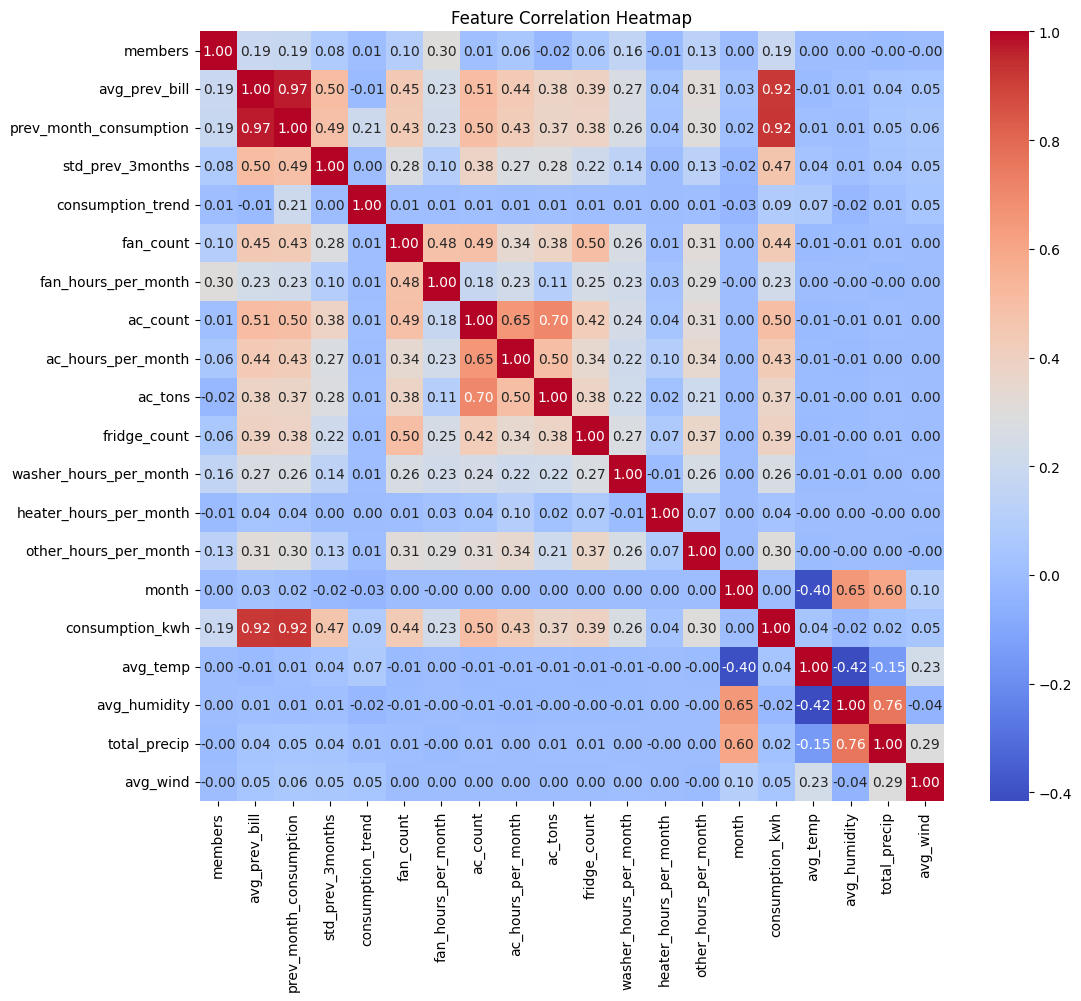

In [24]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

## Step 11 — Explore the Training Dataset

In [25]:
training = pd.read_csv(TRAINING_DATA_PATH)

# Physics-based features derived from appliance usage
training['ac_kwh_est'] = (
    training['ac_count'] * training['ac_hours_per_month'] * training['ac_tons'] * 0.7
)
training['total_load_est'] = (
    training['ac_kwh_est']
    + training['fan_count'] * 0.06 * training['fan_hours_per_month']
    + training['fridge_count'] * 0.15 * 720
    + training['washer_hours_per_month'] * 2.0
    + training['heater_hours_per_month'] * 1.5
    + training['other_hours_per_month'] * 0.3
)

print('Shape:', training.shape)
print()
print('Rows with zero hours per appliance (= appliance not present):')
hour_cols = ['fan_hours_per_month', 'ac_hours_per_month', 'washer_hours_per_month', 'heater_hours_per_month']
for col in hour_cols:
    zeros = (training[col] == 0).sum()
    pct   = zeros / len(training) * 100
    print(f'  {col:<30}: {zeros:,} rows ({pct:.1f}%)')
training.describe().round(2)

Shape: (40124, 24)

Rows with zero hours per appliance (= appliance not present):
  fan_hours_per_month           : 3,212 rows (8.0%)
  ac_hours_per_month            : 35,033 rows (87.3%)
  washer_hours_per_month        : 19,679 rows (49.0%)
  heater_hours_per_month        : 37,077 rows (92.4%)


,members,avg_prev_bill,prev_month_consumption,std_prev_3months,consumption_trend,fan_count,fan_hours_per_month,ac_count,ac_hours_per_month,ac_tons,...,heater_hours_per_month,other_hours_per_month,month,consumption_kwh,avg_temp,avg_humidity,total_precip,avg_wind,ac_kwh_est,total_load_est
count,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,...,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00,40124.00
mean,3.90,125.52,125.87,16.37,0.31,3.31,510.54,0.30,25.11,0.20,...,0.88,199.12,6.50,126.29,26.95,84.79,281.82,16.52,53.71,567.59
std,1.68,101.98,105.57,26.22,40.91,2.20,442.62,0.84,101.37,0.51,...,8.50,218.71,3.45,106.15,0.82,3.05,166.66,2.73,336.39,589.83
min,1.00,0.00,0.00,0.00,-804.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,25.55,77.00,15.00,11.79,0.00,0.00
25%,3.00,65.67,64.00,4.16,-9.00,2.00,212.17,0.00,0.00,0.00,...,0.00,60.62,3.00,64.00,26.20,84.00,139.40,14.21,0.00,276.56
50%,4.00,102.67,102.00,9.00,0.00,3.00,424.34,0.00,0.00,0.00,...,0.00,138.56,7.00,102.37,26.97,85.10,257.00,16.14,0.00,457.10
75%,5.00,155.00,156.00,18.01,9.00,4.00,727.44,0.00,0.00,0.00,...,0.00,260.88,10.00,156.00,27.49,86.29,374.80,19.06,0.00,666.90
max,13.00,979.67,998.00,473.05,903.00,21.00,6365.10,9.00,1333.64,6.67,...,259.80,1887.14,12.00,998.00,29.00,90.33,692.30,21.23,6612.63,8367.78


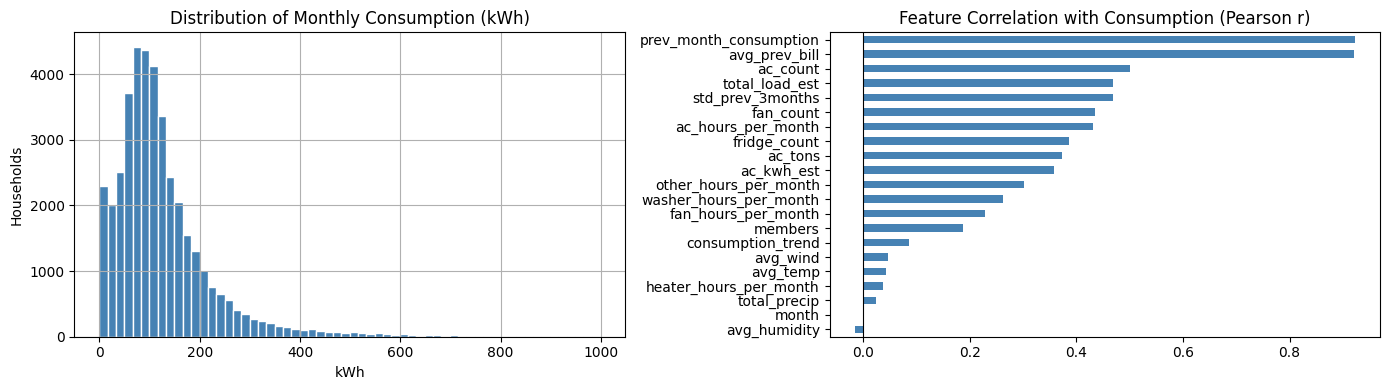

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

training['consumption_kwh'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Monthly Consumption (kWh)')
axes[0].set_xlabel('kWh')
axes[0].set_ylabel('Households')

corr = training[FEATURE_COLS + ['consumption_kwh']].corr()['consumption_kwh'].drop('consumption_kwh').sort_values()
corr.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Correlation with Consumption (Pearson r)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

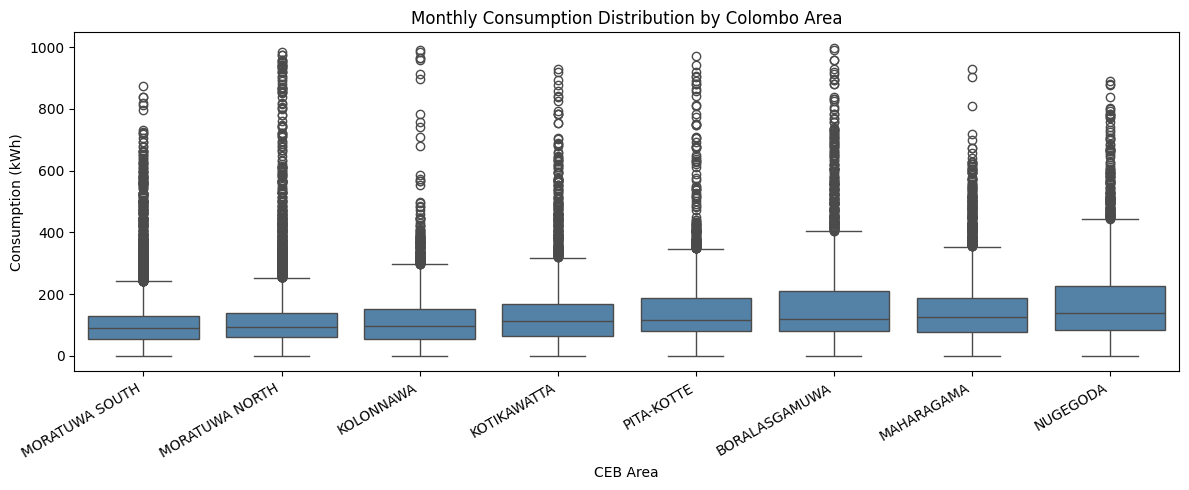

In [27]:
import seaborn as sns

plt.figure(figsize=(12, 5))
area_order = training.groupby('district')['consumption_kwh'].median().sort_values().index
sns.boxplot(data=training, x='district', y='consumption_kwh',
            order=area_order, color='steelblue')
plt.title('Monthly Consumption Distribution by Colombo Area')
plt.xlabel('CEB Area')
plt.ylabel('Consumption (kWh)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

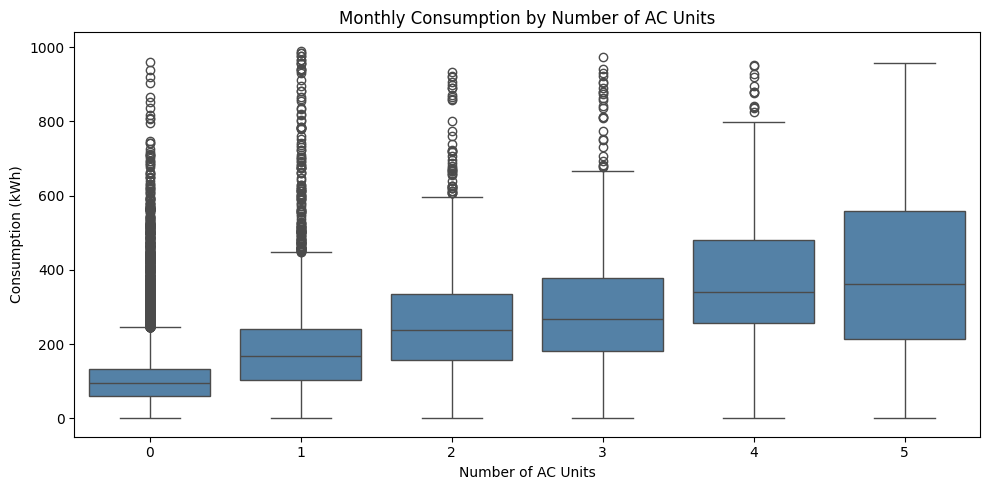

In [28]:
import seaborn as sns

plt.figure(figsize=(10, 5))
plot_data = training[training['ac_count'] <= 5].copy()
plot_data['ac_count'] = plot_data['ac_count'].astype(int)
sns.boxplot(data=plot_data, x='ac_count', y='consumption_kwh', color='steelblue')
plt.title('Monthly Consumption by Number of AC Units')
plt.xlabel('Number of AC Units')
plt.ylabel('Consumption (kWh)')
plt.tight_layout()
plt.show()

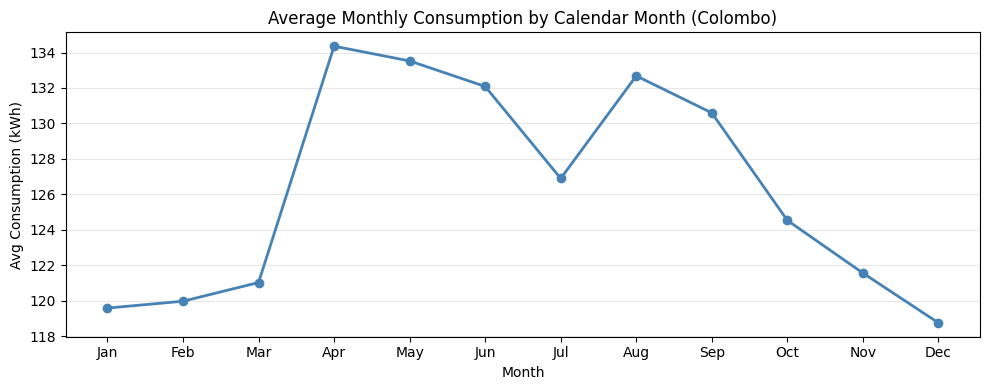

In [29]:
import seaborn as sns

monthly_avg = training.groupby('month')['consumption_kwh'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.plot(monthly_avg['month'], monthly_avg['consumption_kwh'],
         marker='o', color='steelblue', linewidth=2)
plt.xticks(range(1, 13), month_names)
plt.title('Average Monthly Consumption by Calendar Month (Colombo)')
plt.xlabel('Month')
plt.ylabel('Avg Consumption (kWh)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12 — Prepare Data for Training

In [30]:
X = training[FEATURE_COLS]
y = training['consumption_kwh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Features         : {len(FEATURE_COLS)}')

Training samples : 32,099
Test samples     : 8,025
Features         : 21


## Step 13 — Train Models

In [31]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f'{name}: MAE={mae:.2f} kWh   MSE={mse:.2f}   R2={r2:.4f}')
    return {'name': name, 'model': model, 'MAE': round(mae, 2), 'MSE': round(mse, 2), 'R2': round(r2, 4)}

results = []

In [32]:
print('Training Linear Regression (baseline)...')
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate(lr, 'Linear Regression'))

Training Linear Regression (baseline)...
Linear Regression: MAE=19.83 kWh   MSE=1517.61   R2=0.8672


In [33]:
print('Training Random Forest...')
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    max_features=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
results.append(evaluate(rf, 'Random Forest'))

Training Random Forest...


Random Forest: MAE=18.67 kWh   MSE=1330.28   R2=0.8836


In [34]:
print('Training XGBoost...')
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_train, y_train)
results.append(evaluate(xgb, 'XGBoost'))

Training XGBoost...


XGBoost: MAE=18.64 kWh   MSE=1348.02   R2=0.8820


### Hyperparameter Tuning (GridSearchCV)

GridSearchCV with 5-fold cross-validation was run previously across 81 parameter combinations for each model. The optimal parameters found were:

- **Random Forest**: `n_estimators=300, max_depth=15, min_samples_leaf=3, max_features=5`
- **XGBoost**: `n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.7`

These parameters are applied directly in the training cells above. Re-running GridSearchCV (~10 min) is not necessary unless the dataset changes significantly.

## Step 14 — Compare Models & Save Best

In [35]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
results_df = results_df.set_index('name')
print(results_df.to_string())

best = max(results, key=lambda r: r['R2'])
print()
print(f"Best model : {best['name']}  (R2={best['R2']})")

os.makedirs('backend/ml', exist_ok=True)
joblib.dump(best['model'], MODEL_SAVE_PATH)
print(f'Saved to   : {MODEL_SAVE_PATH}')

                     MAE      MSE      R2
name                                     
Linear Regression  19.83  1517.61  0.8672
Random Forest      18.67  1330.28  0.8836
XGBoost            18.64  1348.02  0.8820

Best model : Random Forest  (R2=0.8836)


Saved to   : backend/ml/model.pkl


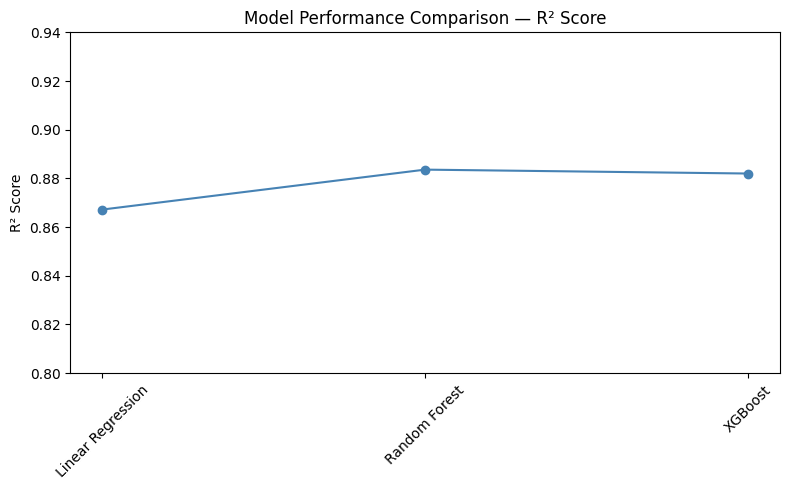

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['R2'], marker='o', linestyle='-', color='steelblue')
plt.yticks(np.arange(0.80, 0.95, 0.02))
plt.xticks(range(len(results_df)), labels=results_df.index.tolist(), rotation=45)
plt.ylabel('R² Score')
plt.title('Model Performance Comparison — R² Score')
plt.tight_layout()
plt.show()

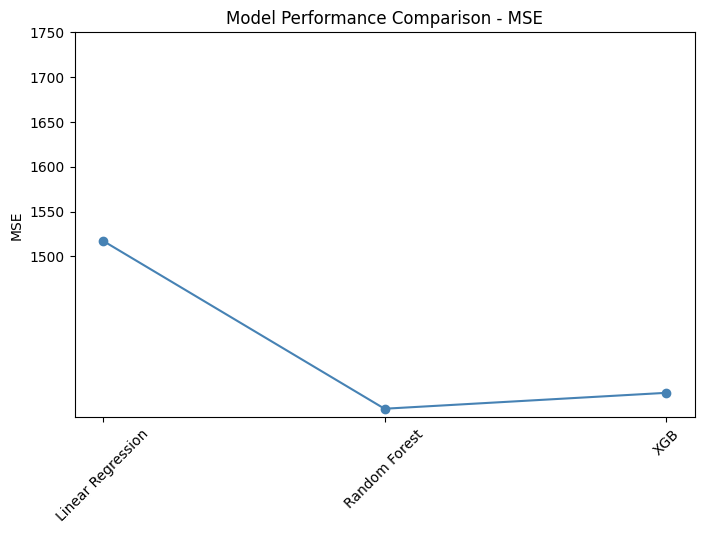

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['MSE'], marker='o', linestyle='-', color='steelblue')
plt.yticks(np.arange(1500, 1800, 50))
plt.xticks(range(len(results_df)), labels=['Linear Regression', 'Random Forest', 'XGB'], rotation=45)
plt.ylabel('MSE')
plt.title('Model Performance Comparison - MSE')
plt.show()

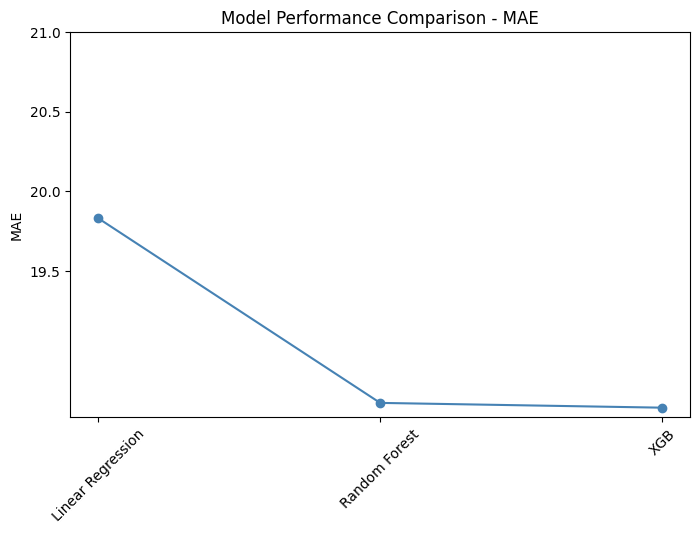

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['MAE'], marker='o', linestyle='-', color='steelblue')
plt.yticks(np.arange(19.5, 21.5, 0.5))
plt.xticks(range(len(results_df)), labels=['Linear Regression', 'Random Forest', 'XGB'], rotation=45)
plt.ylabel('MAE')
plt.title('Model Performance Comparison - MAE')
plt.show()

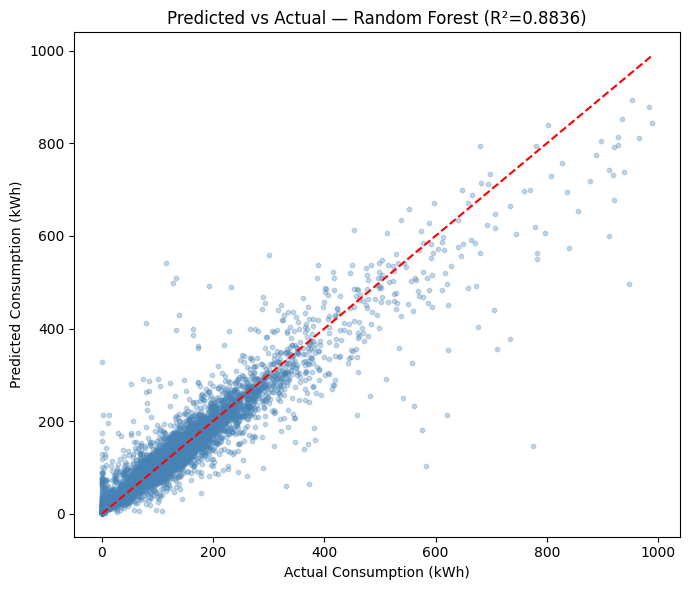

In [39]:
y_pred_test = best['model'].predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Consumption (kWh)')
plt.ylabel('Predicted Consumption (kWh)')
plt.title(f"Predicted vs Actual — {best['name']} (R²={best['R2']})")
plt.tight_layout()
plt.show()

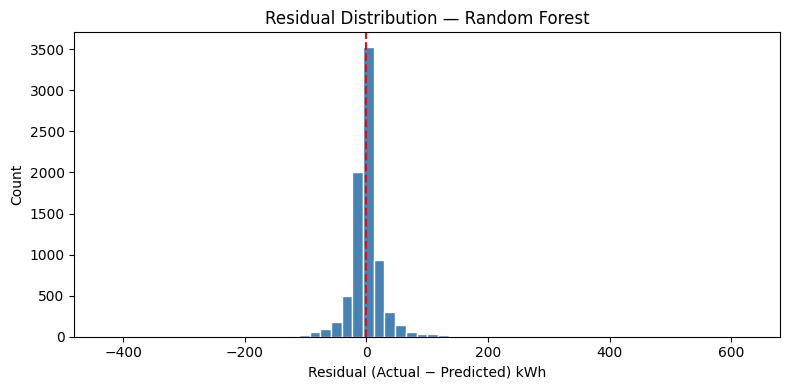

Mean residual   : 0.22 kWh
Std of residuals: 36.47 kWh


In [40]:
residuals = y_test - best['model'].predict(X_test)

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title(f"Residual Distribution — {best['name']}")
plt.xlabel('Residual (Actual − Predicted) kWh')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Mean residual   : {residuals.mean():.2f} kWh")
print(f"Std of residuals: {residuals.std():.2f} kWh")

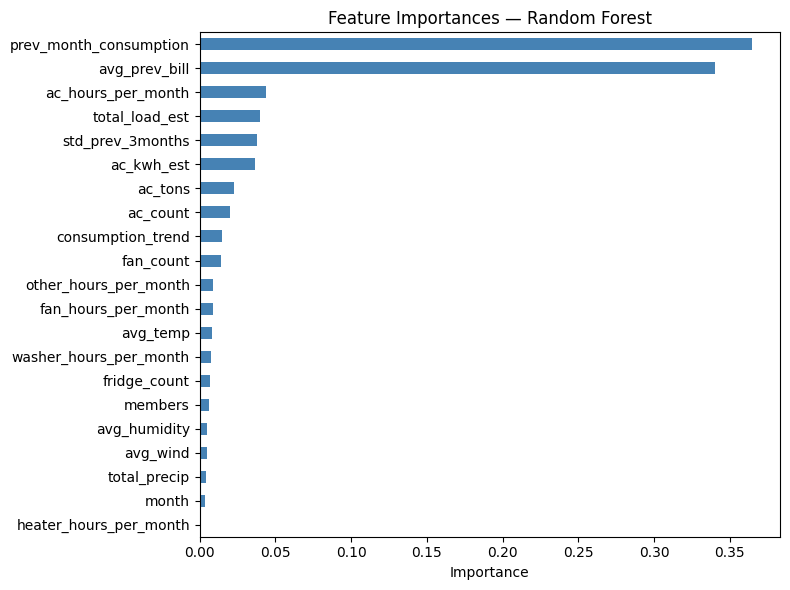

In [41]:
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(
        best['model'].feature_importances_, index=FEATURE_COLS
    ).sort_values()

    fig, ax = plt.subplots(figsize=(8, 6))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f"Feature Importances — {best['name']}")
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances not available for this model type.')